# Testing `analysis.cell_mapping` on a synthetic cell population

`src/MERci/analysis/cell_mapping.py` (Stage B of the cross-microscope
cell-identity-mapping plan) has no real two-experiment cell data to test
against yet -- both `BC555_sample_05` `epi`/`disk` MERlin segmentation runs
are still in progress. This validates the matcher against a **synthetic**
cell population with a known ground-truth correspondence instead, so the
matching logic itself is checked before it is ever pointed at real data.

**Setup**: a jittered-grid "src" population (roughly evenly-spaced, like real
packed tissue, not uniform-random) is transformed by a known similarity
transform plus per-cell registration jitter (simulating the residual local
misalignment Stage A's coarse tissue-boundary fit leaves behind), with 10%
of cells dropped (segmentation misses) and 5% spurious extras added
(segmentation false positives) on the "tgt" side -- then
`match_mutual_nearest_neighbor` and `graph_consistency_filter` are run and
scored against the known ground truth.

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

MERCI_DIR = Path.cwd().parent.parent   # MERci/ (notebook lives in MERci/notebooks/tests/)
sys.path.insert(0, str(MERCI_DIR / "src"))

from MERci.analysis.cell_mapping import (
    build_contact_graph, match_mutual_nearest_neighbor, graph_consistency_filter,
)

PLOT_TITLE_FONTSIZE  = 14
PLOT_LABEL_FONTSIZE  = 12
PLOT_TICK_FONTSIZE   = 11
PLOT_LEGEND_FONTSIZE = 10


## 1 — Build the synthetic population

In [2]:
rng = np.random.default_rng(0)

GRID_N       = 25          # 25x25 = 625 cells
SPACING      = 20.0        # typical cell-to-cell spacing (um)
GRID_JITTER  = 4.0         # random per-cell offset from the ideal grid position
REG_JITTER   = 2.5         # additional per-cell jitter simulating residual Stage-A misalignment
DROP_FRAC    = 0.10        # fraction of src cells with no tgt counterpart (segmentation miss)
SPURIOUS_FRAC = 0.05       # extra tgt-only cells with no src counterpart (false positive)

xx, yy = np.meshgrid(np.arange(GRID_N), np.arange(GRID_N))
src_xy = np.c_[xx.ravel(), yy.ravel()].astype(float) * SPACING
src_xy += rng.normal(0, GRID_JITTER, size=src_xy.shape)
n_src = len(src_xy)

# A handful of deliberately close pairs (cells almost touching) -- the
# scenario most likely to confuse a pure nearest-neighbour matcher.
CLOSE_PAIR_DIST = 3.0
n_close_pairs = 15
close_idx = rng.choice(n_src, size=2 * n_close_pairs, replace=False).reshape(-1, 2)
for i, j in close_idx:
    mid = (src_xy[i] + src_xy[j]) / 2
    direction = rng.normal(size=2)
    direction /= np.linalg.norm(direction)
    src_xy[i] = mid + direction * CLOSE_PAIR_DIST / 2
    src_xy[j] = mid - direction * CLOSE_PAIR_DIST / 2

# Known ground-truth transform (similarity, matching what Stage A already fits).
TRUE_ROTATION_DEG = 22.0
TRUE_SCALE = 1.3
TRUE_TRANSLATION = np.array([500.0, -300.0])
theta = np.radians(TRUE_ROTATION_DEG)
R = np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]])

tgt_true_xy = (src_xy @ R.T) * TRUE_SCALE + TRUE_TRANSLATION
tgt_true_xy += rng.normal(0, REG_JITTER, size=tgt_true_xy.shape)

# Drop some src cells (no tgt counterpart) and add spurious tgt-only cells.
keep_mask = rng.random(n_src) >= DROP_FRAC
tgt_keep_src_idx = np.where(keep_mask)[0]          # which src index each kept tgt row came from
tgt_xy = tgt_true_xy[keep_mask].copy()

n_spurious = int(round(SPURIOUS_FRAC * n_src))
spurious_xy = rng.uniform(tgt_xy.min(0), tgt_xy.max(0), size=(n_spurious, 2))
tgt_xy = np.vstack([tgt_xy, spurious_xy])
# ground_truth[k] = src index that tgt row k came from, or -1 if spurious
ground_truth = np.concatenate([tgt_keep_src_idx, np.full(n_spurious, -1)])

print(f"src cells: {n_src}")
print(f"tgt cells: {len(tgt_xy)}  ({DROP_FRAC:.0%} of src dropped, "
      f"{n_spurious} spurious added)")
print(f"{n_close_pairs} deliberately close src pairs (dist={CLOSE_PAIR_DIST} um) -- "
      f"the population's typical nearest-neighbour spacing is ~{SPACING:.0f} um.")


src cells: 625
tgt cells: 615  (10% of src dropped, 31 spurious added)
15 deliberately close src pairs (dist=3.0 um) -- the population's typical nearest-neighbour spacing is ~20 um.


## 2 — Match, and score against the known ground truth

`match_mutual_nearest_neighbor` assumes both point sets are **already in one shared frame** (its docstring's precondition) -- in the real pipeline that is Stage A's fitted transform applied to `src`; here it is the known ground-truth transform standing in for it, so this cell is matching apples to apples the way Stage B actually would.

`max_dist` is set from the known jitter scale, the way it would be set in practice from the observed residual spread after Stage A (see the plan doc's open questions -- this is exactly the threshold that can't be picked in the abstract, only from real registration-error data).

In [3]:
MAX_DIST = 4 * REG_JITTER   # generous vs. the actual jitter scale, tight vs. SPACING

src_in_tgt_frame = (src_xy @ R.T) * TRUE_SCALE + TRUE_TRANSLATION   # Stage A's job, stood in for here

pairs, distances = match_mutual_nearest_neighbor(src_in_tgt_frame, tgt_xy, max_dist=MAX_DIST)


def score(pairs, label):
    n_correct = sum(1 for i, j in pairs if ground_truth[j] == i)
    n_wrong = len(pairs) - n_correct
    n_possible = keep_mask.sum()   # src cells that actually have a tgt counterpart
    precision = n_correct / len(pairs) if pairs else float("nan")
    recall = n_correct / n_possible
    print(f"{label:30s}  matched={len(pairs):4d}  correct={n_correct:4d}  "
          f"wrong={n_wrong:3d}  precision={precision:.3f}  recall={recall:.3f}")
    return n_correct, n_wrong, precision, recall


print(f"src cells with a real tgt counterpart: {int(keep_mask.sum())}/{n_src}\n")
mnn_correct, mnn_wrong, mnn_prec, mnn_rec = score(pairs, "mutual nearest-neighbour")


src cells with a real tgt counterpart: 584/625

mutual nearest-neighbour        matched= 574  correct= 564  wrong= 10  precision=0.983  recall=0.966


## 3 — Contact-graph consistency filter

Contact distance set to ~1.5x each population's own typical spacing (`tgt`'s is `TRUE_SCALE` times `src`'s, since the two experiments' pixel/segmentation scales genuinely differ -- real usage: set each from the observed cell-to-cell spacing in that experiment's own segmentation).

In [4]:
CONTACT_DIST_SRC = 1.5 * SPACING
CONTACT_DIST_TGT = 1.5 * SPACING * TRUE_SCALE

src_adjacency = build_contact_graph(src_xy, CONTACT_DIST_SRC)
tgt_adjacency = build_contact_graph(tgt_xy, CONTACT_DIST_TGT)

mean_degree = np.mean([len(v) for v in src_adjacency.values()])
print(f"src contact graph: mean degree = {mean_degree:.1f} "
      f"(contact_dist={CONTACT_DIST_SRC:.0f} um)")

filtered_pairs = graph_consistency_filter(pairs, src_adjacency, tgt_adjacency, min_fraction=0.5)
gf_correct, gf_wrong, gf_prec, gf_rec = score(filtered_pairs, "+ graph consistency filter")

print(f"\nRemoved {len(pairs) - len(filtered_pairs)} candidate matches "
      f"({sum(1 for i, j in pairs if ground_truth[j] != i) - gf_wrong} of them wrong).")


src contact graph: mean degree = 6.1 (contact_dist=30 um)
+ graph consistency filter      matched= 570  correct= 560  wrong= 10  precision=0.982  recall=0.959

Removed 4 candidate matches (0 of them wrong).


## 4 — Visualize

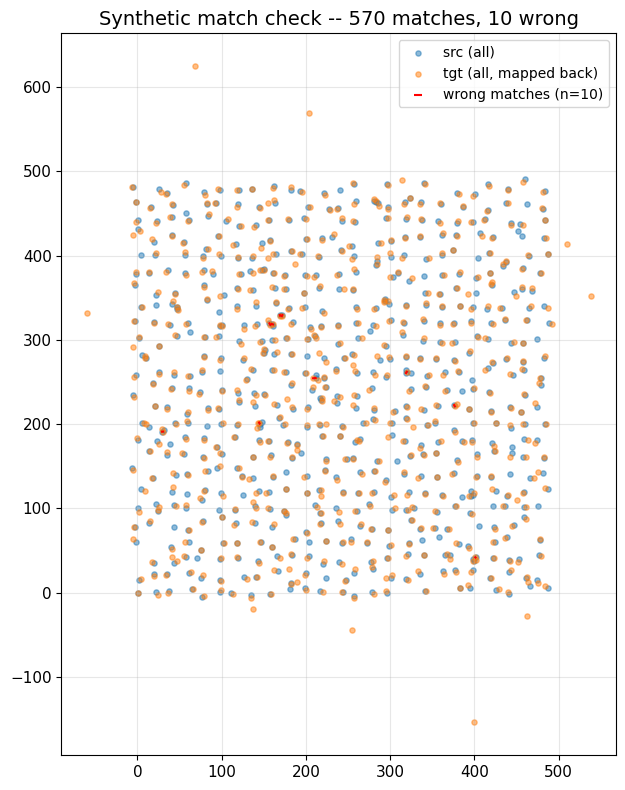

In [5]:
fig, ax = plt.subplots(figsize=(8, 8))

matched_tgt_idx = {j for _, j in filtered_pairs}
wrong_pairs = [(i, j) for i, j in filtered_pairs if ground_truth[j] != i]

# map matched tgt centroids back toward src space for a same-frame overlay
tgt_in_src_frame = ((tgt_xy - TRUE_TRANSLATION) / TRUE_SCALE) @ R

ax.scatter(src_xy[:, 0], src_xy[:, 1], s=14, color="tab:blue", alpha=0.5, label="src (all)")
ax.scatter(tgt_in_src_frame[:, 0], tgt_in_src_frame[:, 1], s=14, color="tab:orange",
           alpha=0.5, label="tgt (all, mapped back)")
for i, j in wrong_pairs:
    ax.plot([src_xy[i, 0], tgt_in_src_frame[j, 0]],
            [src_xy[i, 1], tgt_in_src_frame[j, 1]], "-", color="red", lw=1.5, zorder=5)
ax.scatter([], [], color="red", marker="_", label=f"wrong matches (n={len(wrong_pairs)})")

ax.set_title(f"Synthetic match check -- {len(filtered_pairs)} matches, "
             f"{len(wrong_pairs)} wrong", fontsize=PLOT_TITLE_FONTSIZE)
ax.tick_params(labelsize=PLOT_TICK_FONTSIZE)
ax.legend(fontsize=PLOT_LEGEND_FONTSIZE, loc="upper right")
ax.set_aspect("equal"); ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()


## Conclusion

Numbers above are read directly from the run (not asserted to a pre-decided outcome) -- see the printed precision/recall for both the raw mutual-nearest-neighbour matcher and the graph-consistency-filtered result, and how many of the removed candidates were actually wrong. This is a synthetic stand-in only: real `epi`/`disk` cell populations will have their own actual jitter/drop/spurious-match rates, not these chosen constants -- re-run this style of check against the real `match_mutual_nearest_neighbor` output once both experiments' `feature_metadata.csv` exist, using the *real* residual spread to pick `max_dist`/`contact_dist` rather than the synthetic values used here.